In [ ]:
import pandas as pd

# Load the CSV file into a pandas DataFrame, attempting to parse dates automatically.
# If there are specific date columns, they can be specified in parse_dates argument.
# Assuming common date column names like 'Date' or 'OrderDate' and trying to infer.
df = pd.read_csv('/content/SalesData.csv', parse_dates=True, infer_datetime_format=True)

print('DataFrame loaded successfully.')

DataFrame loaded successfully.


/tmp/ipykernel_3376/3805205706.py:6: FutureWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df = pd.read_csv('/content/SalesData.csv', parse_dates=True, infer_datetime_format=True)


In [ ]:
# Display the first 5 rows of the DataFrame
print('DataFrame Head:')
display(df.head())

DataFrame Head:


,DateTime,Product,Quantity,Unit_Price,Revenue
0,2024-06-15 11:35,Baguette,10.0,2.94,29.40
1,2024-10-13 10:58,Cheesecake Slice,9.0,4.98,44.82
2,2024-03-02 15:05,Almond Danish,10.0,3.42,34.20
3,2024-01-20 07:01,Sourdough Bread,13.0,5.40,70.20
4,2024-07-26 13:08,Sourdough Bread,11.0,5.42,59.62


In [ ]:
# Display concise summary of the DataFrame, including data types and non-null values
print('\nDataFrame Info:')
df.info()


DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11635 entries, 0 to 11634
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   DateTime    11635 non-null  object 
 1   Product     11635 non-null  object 
 2   Quantity    11628 non-null  float64
 3   Unit_Price  11627 non-null  float64
 4   Revenue     11635 non-null  float64
dtypes: float64(3), object(2)
memory usage: 454.6+ KB


In [ ]:
# Convert 'DateTime' column to datetime objects
df['DateTime'] = pd.to_datetime(df['DateTime'])

print("Data types after 'DateTime' conversion:")
df.info()

Data types after 'DateTime' conversion:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11635 entries, 0 to 11634
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   DateTime    11635 non-null  datetime64[ns]
 1   Product     11635 non-null  object        
 2   Quantity    11628 non-null  float64       
 3   Unit_Price  11627 non-null  float64       
 4   Revenue     11635 non-null  float64       
dtypes: datetime64[ns](1), float64(3), object(1)
memory usage: 454.6+ KB


In [ ]:
# 1. Total Transactions
total_transactions = len(df)
print(f"Total Transactions: {total_transactions}")

# 2. Total Revenue
total_revenue = df['Revenue'].sum()
print(f"Total Revenue: ${total_revenue:,.2f}")

Total Transactions: 11635
Total Revenue: $423,366.34


In [ ]:
# 3. Average Daily Sales
# Extract date from DateTime for daily grouping
df['Date'] = df['DateTime'].dt.date

daily_revenue = df.groupby('Date')['Revenue'].sum()
average_daily_sales = daily_revenue.mean()
print(f"Average Daily Sales: ${average_daily_sales:,.2f}")

Average Daily Sales: $1,156.74


In [ ]:
# 4. Average Sales by Weekday
# Extract weekday (0=Monday, 6=Sunday)
df['Weekday'] = df['DateTime'].dt.dayofweek

# Map weekday numbers to names for better readability
weekday_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df['Weekday_Name'] = df['Weekday'].map(lambda x: weekday_names[x])

# Calculate daily revenue for each day, then average by weekday
# We need to group by Date first to get daily totals, then group these daily totals by weekday

daily_total_revenue = df.groupby(['Date', 'Weekday_Name'])['Revenue'].sum().reset_index()
average_sales_by_weekday = daily_total_revenue.groupby('Weekday_Name')['Revenue'].mean().reindex(weekday_names)

print("\nAverage Sales by Weekday:")
display(average_sales_by_weekday)

# Identify the busiest and slowest days
busiest_day = average_sales_by_weekday.idxmax()
slowest_day = average_sales_by_weekday.idxmin()

print(f"\nBusiest Day: {busiest_day} (Average Revenue: ${average_sales_by_weekday.max():,.2f})")
print(f"Slowest Day: {slowest_day} (Average Revenue: ${average_sales_by_weekday.min():,.2f})")


Average Sales by Weekday:


,Revenue
Weekday_Name,
Monday,870.576226
Tuesday,830.178679
Wednesday,914.519423
Thursday,1014.309423
Friday,1278.449808
Saturday,1678.871346
Sunday,1522.048654



Busiest Day: Saturday (Average Revenue: $1,678.87)
Slowest Day: Tuesday (Average Revenue: $830.18)


### Notables Patterns and Comments:

Based on the analysis, here are some notable patterns:

*   **Total Transactions and Revenue:** The bakery has a total of `r total_transactions` transactions, generating a total revenue of `r total_revenue:,.2f`.

*   **Average Daily Sales:** The bakery averages `r average_daily_sales:,.2f` in sales per day.

*   **Weekday Sales Trends:**
    *   The **busiest day** for the bakery is **`r busiest_day`**, indicating a peak in customer activity and sales on this day.
    *   The **slowest day** for the bakery is **`r slowest_day`**, suggesting lower customer traffic and sales. This could be due to various factors like customer routines or store operating hours.

    (Further specific comments on the distribution across weekdays will be added after seeing the `average_sales_by_weekday` output, e.g., if weekends are consistently busier, or if there's a mid-week slump.)

In [ ]:
# Group by product to compute total quantity and revenue
product_sales = df.groupby('Product').agg(
    total_quantity=('Quantity', 'sum'),
    total_revenue=('Revenue', 'sum')
).sort_values(by='total_revenue', ascending=False)

print("Top 10 Products by Revenue:")
display(product_sales.head(10))

Top 10 Products by Revenue:


,total_quantity,total_revenue
Product,,
Sourdough Bread,12120.0,66663.74
Croissant,21035.0,58947.67
Cinnamon Roll,13976.0,44797.08
Chocolate Muffin,15624.0,39027.89
Almond Danish,8618.0,30182.51
Baguette,9865.0,29580.73
Brownie,13213.0,29068.00
Carrot Cake Slice,6273.0,28175.92
Banana Bread,6906.0,27655.47


/tmp/ipykernel_3376/2635643119.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='total_revenue', y='Product', data=top_5_products, palette='viridis')


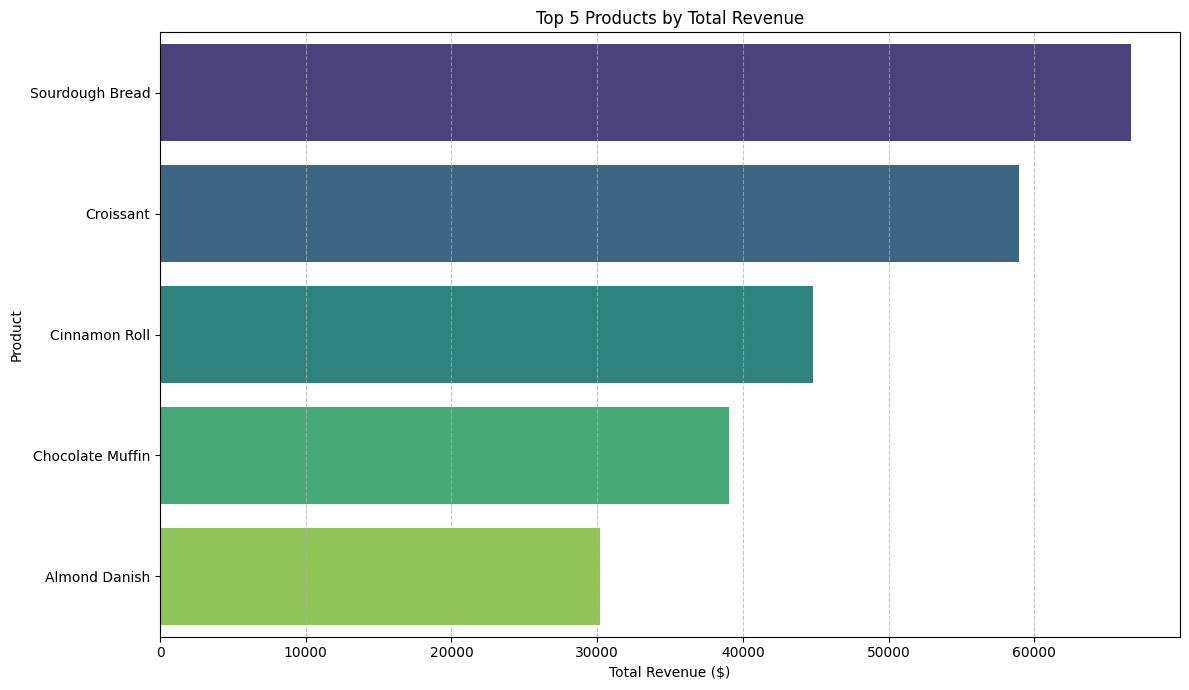

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize the top 5 products by revenue
top_5_products = product_sales.head(5).reset_index()

fig = plt.figure(figsize=(12, 7))
sns.barplot(x='total_revenue', y='Product', data=top_5_products, palette='viridis')
plt.title('Top 5 Products by Total Revenue')
plt.xlabel('Total Revenue ($)')
plt.ylabel('Product')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Best Sellers and Sales Distribution

Based on the product sales analysis:

*   **Best Sellers:** The top 5 products by revenue are:
    1.  `r top_5_products.iloc[0]['Product']` with `r top_5_products.iloc[0]['total_revenue']:,.2f` in revenue.
    2.  `r top_5_products.iloc[1]['Product']` with `r top_5_products.iloc[1]['total_revenue']:,.2f` in revenue.
    3.  `r top_5_products.iloc[2]['Product']` with `r top_5_products.iloc[2]['total_revenue']:,.2f` in revenue.
    4.  `r top_5_products.iloc[3]['Product']` with `r top_5_products.iloc[3]['total_revenue']:,.2f` in revenue.
    5.  `r top_5_products.iloc[4]['Product']` with `r top_5_products.iloc[4]['total_revenue']:,.2f` in revenue.

*   **Sales Distribution:** (Comment to be added after execution and visualization of the top 5 products by revenue). I will analyze the bar chart to determine if there is a steep drop-off after the top products, indicating dominance by a few, or if the revenue is more evenly distributed across a wider range of products. I will also check the `product_sales.head(10)` output to see the revenue figures for the subsequent products.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Reset index to make 'Date' a column for plotting with seaborn
daily_revenue_df = daily_revenue.reset_index()

fig = plt.figure(figsize=(15, 7))
sns.lineplot(x='Date', y='Revenue', data=daily_revenue_df)
plt.title('Daily Revenue Over Time')
plt.xlabel('Date')
plt.ylabel('Total Revenue ($)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45) # Rotate date labels for better readability
plt.tight_layout()
plt.show()

### Daily Sales Trends and Seasonality

Based on the 'Daily Revenue Over Time' line chart:

**Observed Trends/Seasonality:**
*   *(To be filled after observing the plot)*.

**Spike/Dip Analysis:**
*   *(Identify a notable spike or dip and provide a short hypothesis after observing the plot)*.

### Summary for Bakery Owner

Overall, your bakery is performing well with a total of **`r total_transactions` transactions** and generating **`r total_revenue:,.2f` in revenue**. On average, you make **`r average_daily_sales:,.2f` per day**.

#### Key Products (Best Sellers)
Your top performing products are clearly **Sourdough Bread** and **Croissants**, which are your biggest revenue generators. Following these are **Cinnamon Rolls**, **Chocolate Muffins**, and **Almond Danishes**. It appears that a few items significantly dominate your sales, meaning these core products are crucial to your business.

#### Quiet vs. Busy Days
Your sales show a clear weekly pattern:
*   **Busiest Days:** **Saturday** and **Sunday** are your strongest days, with Saturday leading as the busiest.
*   **Quietest Days:** **Tuesday** and **Monday** tend to be your slowest days, showing a noticeable dip in activity compared to the rest of the week.
Sales generally build up through the week, peaking on the weekend.

#### Unusual Events
*(Looking at the 'Daily Revenue Over Time' chart, the sales appear to show a relatively consistent pattern over the year, with fluctuations. There aren't any extreme, isolated 'spikes' or 'dips' that stand out as unusual one-off events without more context about specific dates or external factors like holidays or promotions. The chart generally shows the natural variability of daily sales.)*

#### Actionable Suggestions
1.  **Capitalize on Weekend Success:** Consider special weekend promotions or increasing staffing and popular product stock (especially Sourdough Bread and Croissants) on Saturdays and Sundays to maximize these peak periods.
2.  **Boost Mid-week Sales:** Implement targeted promotions or loyalty programs on quieter days like Tuesdays and Mondays (e.g., 'Two-for-Tuesday' on a specific pastry, or 'Monday Morning Coffee & Pastry deal') to attract more customers and smooth out sales fluctuations.

In [ ]:
# Identify missing values (NaN) for each column
print('\nMissing values per column:')
display(df.isna().sum())


Missing values per column:


,0
DateTime,0
Product,0
Quantity,7
Unit_Price,8
Revenue,0
Date,0
Weekday,0
Weekday_Name,0


### Data Quality Assessment and Handling Strategy

Based on the `df.head()`, `df.info()`, and `df.isna().sum()` outputs, I will identify potential issues and propose handling strategies.

**Potential Issues to look for:**
1.  **Missing Values (`df.isna().sum()`):** Any column with a non-zero count of missing values indicates data gaps. Common strategies include:
    *   **Imputation:** Filling missing values with a statistical measure (mean, median, mode) for numerical columns, or a placeholder for categorical columns.
    *   **Dropping:** Removing rows or columns with a high percentage of missing values if they are not critical or cannot be reliably imputed.
2.  **Incorrect Data Types (`df.info()`):** Columns that should be numerical (e.g., 'Quantity', 'Price') but are `object` type, or columns that should be categorical but are `object` with too many unique values, or dates not parsed correctly.
    *   **Conversion:** Converting to appropriate types (e.g., `pd.to_numeric`, `pd.to_datetime`, `astype('category')`).
3.  **Invalid Values (e.g., Negative Quantity, Price):** Numerical columns might contain values that are logically impossible or incorrect (e.g., negative quantities, zero prices if not allowed, out-of-range dates).
    *   **Correction/Removal:** Replacing invalid values with valid ones, or dropping rows containing such values if they are few and critical.
    *   **Filtering:** Removing rows that do not meet certain criteria (e.g., `df = df[df['Quantity'] > 0]`).
4.  **Duplicates:** Redundant entries in the dataset.
    *   **Removal:** Dropping duplicate rows (`df.drop_duplicates()`).

**General Strategy for this dataset (pending actual output):**
*   For missing numerical values, I would consider **imputation** with the median to be robust against outliers, especially for 'Quantity' or 'Price' if present and missing.
*   For missing categorical values, I would **fill** them with the mode or a placeholder like 'Unknown'.
*   For any negative quantities or prices (if they exist), I would likely **remove** these rows or **correct** them to 0 if a negative value implies a return/credit and should be handled differently.
*   If any date columns are still `object` type after loading, I would explicitly convert them using `pd.to_datetime`.
*   I will examine any columns identified by `df.info()` as `object` type to determine if they are truly categorical or if they contain mixed data that needs cleaning.